## Imports iniciais

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as st

## Leitura e visualização dos arquivos

In [2]:
df_trips_amount = pd.read_csv('trips_amount.csv')
df_neighborhood_avg_trips = pd.read_csv('neighborhood_avg_trips.csv')
df_trips_to_airport = pd.read_csv('trips_to_airport.csv')

In [3]:
dfs = {
    "Trips Amount": df_trips_amount,
    "Neighborhood Avg Trips": df_neighborhood_avg_trips,
    "Trips To Airport": df_trips_to_airport,
}

for name, df in dfs.items():
    print(f"{name.upper()}")
    print()
    df.info()
    display(df.head())

TRIPS AMOUNT

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   company_name  64 non-null     str  
 1   trips_amount  64 non-null     int64
dtypes: int64(1), str(1)
memory usage: 1.1 KB


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


NEIGHBORHOOD AVG TRIPS

<class 'pandas.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     str    
 1   average_trips          94 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.6 KB


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


TRIPS TO AIRPORT

<class 'pandas.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   str    
 1   weather_conditions  1068 non-null   str    
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), str(2)
memory usage: 25.2 KB


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [4]:
df_trips_to_airport['start_ts'] = pd.to_datetime(df_trips_to_airport['start_ts']) # Define a coluna 'start_ts' como datetime
df_trips_to_airport['start_ts'].info()

<class 'pandas.Series'>
RangeIndex: 1068 entries, 0 to 1067
Series name: start_ts
Non-Null Count  Dtype         
--------------  -----         
1068 non-null   datetime64[us]
dtypes: datetime64[us](1)
memory usage: 8.5 KB


## Análise exploratória dos dados

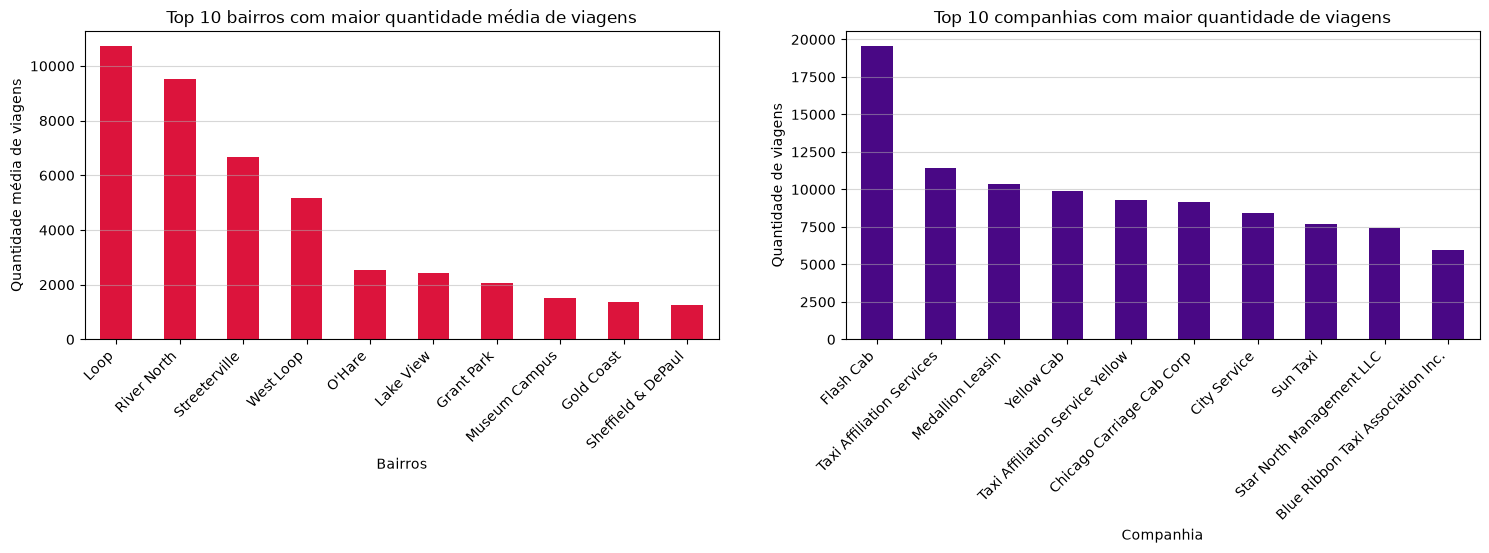

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18,4))
df_neighborhood_avg_trips.sort_values(
    by='average_trips', ascending=False).head(10).plot(
                    kind='bar',
                    x='dropoff_location_name',
                    y='average_trips',
                    title='Top 10 bairros com maior quantidade média de viagens',
                    xlabel='Bairros',
                    ylabel='Quantidade média de viagens',
                    color="crimson",
                    ax=ax1)
ax1.legend().remove()
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.5)

df_trips_amount.sort_values(
    by='trips_amount', ascending=False).head(10).plot(
                    kind='bar',
                    x='company_name',
                    y='trips_amount',
                    title='Top 10 companhias com maior quantidade de viagens',
                    xlabel='Companhia',
                    ylabel='Quantidade de viagens',
                    color="#490885",
                    ax=ax2)
ax2.legend().remove()
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.5)
plt.show()

## O que os graficos apontam?

O primeiro gráfico nos mostra que os destinos principais das companhias são os centros comerciais, por isso concentram mais desembarques.\
Em soma Flash Cab mostra uma alta discrepância em relação as outras empresas, que apresentam uma maior distribuição, o que essa companhia oferece de diferente?

## Teste de hipóteses

Hipótese nula: A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare **não** muda nos sábados chuvosos.\
\
Hipótese alternativa: A duração média dos passeios do Loop para o Aeroporto Internacional O'Hare muda nos sábados chuvosos.

In [7]:
weather_good = df_trips_to_airport[df_trips_to_airport['weather_conditions'] == 'Good']['duration_seconds']
weather_bad = df_trips_to_airport[df_trips_to_airport['weather_conditions'] == 'Bad']['duration_seconds']
print(f'Variância das viagens em condições climáticas boas: {round(weather_good.var(),2)}')
print(f'Variância das viagens em condições climáticas ruins: {round(weather_bad.var(),2)}')

alpha = 0.05
results = st.ttest_ind(weather_good, weather_bad, equal_var=False)
print(f'p-value: {results.pvalue}')

if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula. Há diferença significativa entre as durações das viagens em condições climáticas boas e ruins.")
else:
    print("Não rejeitamos a hipótese nula. Não há diferença significativa entre as durações das viagens em condições climáticas boas e ruins.")


Variância das viagens em condições climáticas boas: 576382.01
Variância das viagens em condições climáticas ruins: 520294.09
p-value: 6.738994326108735e-12
Rejeitamos a hipótese nula. Há diferença significativa entre as durações das viagens em condições climáticas boas e ruins.


A definição do limiar como 0.05 se dá ao fato de que é um contexto exploratório, sem alto custo associado a um falso positivo.

# Conclusão

O teste da hipótese determina que podemos rejeitar a hipótese nula, ou seja, o clima tem relação com o tempo de viagem.